# Run agents from an existing JSON task family

This notebook is the fast execution path for a task family that has already been
designed or edited elsewhere. It reads one JSON file, performs only structural and
agent-interoperability checks, builds fresh environments, and runs the four agent
variants on a common episode schedule.

It intentionally does **not** run the expensive known-MDP difficulty audit. Use the
audit cell in `hierarchical_task_playground.ipynb` before treating a design as
difficulty-matched or ready for confirmatory human data.

In [30]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np

from hierarchical_gridworld import (
    load_task_family,
    make_task_environments,
    plot_task,
    validate_task_family,
)
from environments import generate_sticky_env_sequence
from recovery import simulate_diner, simulate_fresh_start, simulate_persistent
from stochastic_crp_dyna_agent import AgentConfig, StochasticSoftmaxCRPDyna


# Edit these settings, then rerun from the JSON-loading cell onward.
JSON_PATH = Path("four_task_family_default_acceptable.json")
SEED = 2026
SCHEDULE_MODE = "round_robin"       # or "sticky"
EPISODES_PER_TASK = 8                # increase for a planned run
STAY_PROB = 0.80                     # used only when SCHEDULE_MODE == "sticky"

REFERENCE_ETA = 0.30
REFERENCE_GAMMA = 0.95
REFERENCE_TAU = 0.50
PLANNING_STEPS = 10                   # increase after the smoke test
REFERENCE_N_PROBE = 8

STOCHASTIC_N_PROBE = 8
STOCHASTIC_PROBE_SAMPLES = 4         # increase for a planned run
STOCHASTIC_PROBE_ETA = 0.30
STOCHASTIC_MODEL_ETA = 0.30
STOCHASTIC_FINGERPRINT_ETA = 0.30
STOCHASTIC_ASSIGNMENT_MODE = "sample"  # or "map"

np.random.seed(SEED)
random.seed(SEED)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load the JSON and perform fast structural checks

The JSON is the source of truth. A missing or `null` `difficulty_audit` field is
allowed. `validate_task_family` checks the crossed four-task design and common
state/action encoding; it does not solve any MDP.

In [31]:
if not JSON_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {JSON_PATH}. Set JSON_PATH to an existing task-family JSON."
    )

specs = load_task_family(JSON_PATH)
summary = validate_task_family(specs)
payload = json.loads(JSON_PATH.read_text(encoding="utf-8"))

state_counts = {
    name: make_task_environments({name: spec})[name].observation_space.n
    for name, spec in specs.items()
}
if len(set(state_counts.values())) != 1:
    raise ValueError(f"Tasks do not share one observation-space size: {state_counts}")

print(f"Loaded {JSON_PATH}")
print(f"Structural validation: {summary['n_tasks']} tasks, "
      f"{summary['n_distinct_wall_layouts']} wall layouts, "
      f"{summary['n_distinct_outcome_layouts']} outcome maps")
print(f"Shared observation-space size: {next(iter(state_counts.values()))}")
print("Stored difficulty audit:",
      "present" if payload.get("difficulty_audit") is not None else "none")
for name, spec in specs.items():
    print(f"{name:20s}: {spec.transition_mode:13s} × "
          f"{spec.objective_mode:14s}; slip={spec.slip_prob:.2f}; "
          f"max_steps={spec.max_steps}")

Loaded four_task_family_default_acceptable.json
Structural validation: 4 tasks, 4 wall layouts, 2 outcome maps
Shared observation-space size: 1600
Stored difficulty audit: present
deterministic_gain  : deterministic × gain          ; slip=0.00; max_steps=120
deterministic_loss  : deterministic × loss_avoidance; slip=0.00; max_steps=120
stochastic_gain     : stochastic    × gain          ; slip=0.20; max_steps=120
stochastic_loss     : stochastic    × loss_avoidance; slip=0.20; max_steps=120


## 2. Inspect the loaded task layouts

This is a designer visualization only. Outcomes are revealed here so that a saved
JSON can be checked before an agent is run; the agent itself receives no task label
or hidden outcome map.

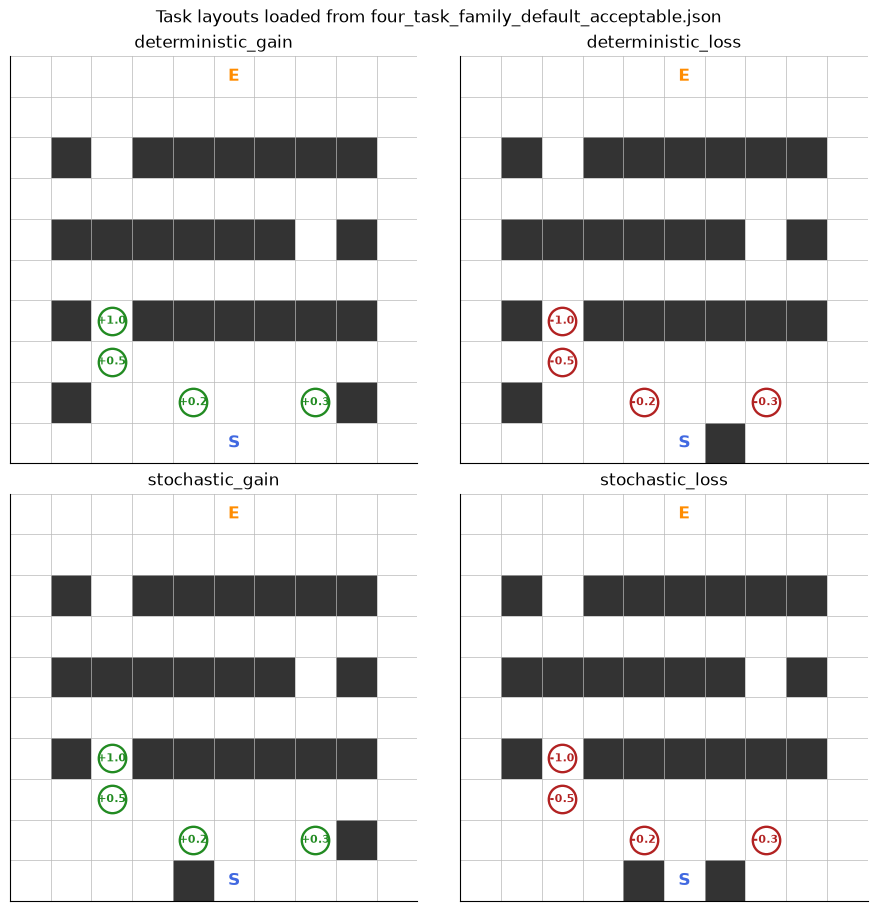

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9), constrained_layout=True)
for ax, (name, spec) in zip(axes.flat, specs.items()):
    plot_task(spec, ax, reveal_outcomes=True, title=name)
fig.suptitle(f"Task layouts loaded from {JSON_PATH.name}")
plt.show()

## 3. Freeze one common episode schedule

Every model receives the same task sequence. A round-robin schedule is useful for a
quick smoke test. A sticky schedule creates recurrent blocks and is more suitable
for studying context reuse. The schedule itself contains names for simulation
bookkeeping; names are never placed in the environment observation or `info`.

In [33]:
task_names = list(specs)
if SCHEDULE_MODE == "round_robin":
    episode_sequence = task_names * int(EPISODES_PER_TASK)
elif SCHEDULE_MODE == "sticky":
    episode_sequence = generate_sticky_env_sequence(
        task_names,
        episodes=len(task_names) * int(EPISODES_PER_TASK),
        stay_prob=STAY_PROB,
        seed=SEED,
    )
else:
    raise ValueError("SCHEDULE_MODE must be 'round_robin' or 'sticky'")

print(f"Schedule mode: {SCHEDULE_MODE}; episodes: {len(episode_sequence)}")
print("Sequence:", episode_sequence)

Schedule mode: round_robin; episodes: 32
Sequence: ['deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss', 'deterministic_gain', 'deterministic_loss', 'stochastic_gain', 'stochastic_loss']


## 4. Run the three reference softmax agents

Each model receives freshly constructed environments with the same seed. This keeps
environment state and random-number consumption from leaking between comparisons.

In [34]:
def fresh_envs(seed):
    return make_task_environments(specs, seed=seed)


reference_common = dict(
    eta=REFERENCE_ETA,
    gamma=REFERENCE_GAMMA,
    tau=REFERENCE_TAU,
    planning_steps=PLANNING_STEPS,
)

fresh_returns, fresh_trajectories = simulate_fresh_start(
    episode_sequence, fresh_envs(SEED + 1), **reference_common, seed=SEED + 1
)
persistent_returns, persistent_trajectories = simulate_persistent(
    episode_sequence, fresh_envs(SEED + 1), **reference_common, seed=SEED + 1
)
reference_diner_returns, reference_assignments, reference_trajectories = simulate_diner(
    episode_sequence,
    fresh_envs(SEED + 1),
    crp_alpha=0.50,
    n_probe=REFERENCE_N_PROBE,
    **reference_common,
    seed=SEED + 1,
)

print("Reference agents completed.")
print("Reference DINER assignments:", reference_assignments)

Reference agents completed.
Reference DINER assignments: [0, 1, 2, 3, 0, 1, 4, 5, 0, 1, 4, 6, 0, 1, 7, 5, 0, 1, 8, 5, 0, 1, 9, 10, 0, 1, 11, 12, 0, 1, 13, 10]


## 5. Run stochastic softmax CRP-Dyna

This agent uses repeated stochastic probes, graded JSD diagnostics, Bayesian CRP
assignment, delta-rule transition learning, and stochastic Dyna replay. The
configuration below is intentionally small enough for a smoke test.

In [35]:
stochastic_envs = fresh_envs(SEED + 2)
first_env = stochastic_envs[episode_sequence[0]]
stochastic_config = AgentConfig(
    eta=REFERENCE_ETA,
    gamma=REFERENCE_GAMMA,
    tau=REFERENCE_TAU,
    crp_alpha=0.50,
    planning_steps=PLANNING_STEPS,
    n_probe=STOCHASTIC_N_PROBE,
    probe_samples_per_step=STOCHASTIC_PROBE_SAMPLES,
    probe_eta=STOCHASTIC_PROBE_ETA,
    model_eta=STOCHASTIC_MODEL_ETA,
    fingerprint_update_eta=STOCHASTIC_FINGERPRINT_ETA,
    assignment_mode=STOCHASTIC_ASSIGNMENT_MODE,
)
stochastic_agent = StochasticSoftmaxCRPDyna(
    n_states=first_env.observation_space.n,
    n_actions=first_env.action_space.n,
    config=stochastic_config,
    seed=SEED + 2,
)
stochastic_result = stochastic_agent.play_sequence(
    episode_sequence, stochastic_envs
)

print("Stochastic CRP-Dyna completed.")
print("Inferred contexts:", len(stochastic_agent.contexts))
print("Assignments:", stochastic_result.assignments)

Stochastic CRP-Dyna completed.
Inferred contexts: 6
Assignments: [0, 1, 2, 3, 0, 1, 4, 3, 0, 1, 5, 3, 0, 1, 4, 3, 0, 1, 5, 3, 0, 1, 4, 3, 0, 1, 4, 3, 0, 1, 4, 3]


## 6. Compare returns and context assignments

These plots are execution diagnostics, not a difficulty audit. For a substantive
comparison, increase the schedule length, repeat across seeds, and report uncertainty
rather than interpreting one smoke run.

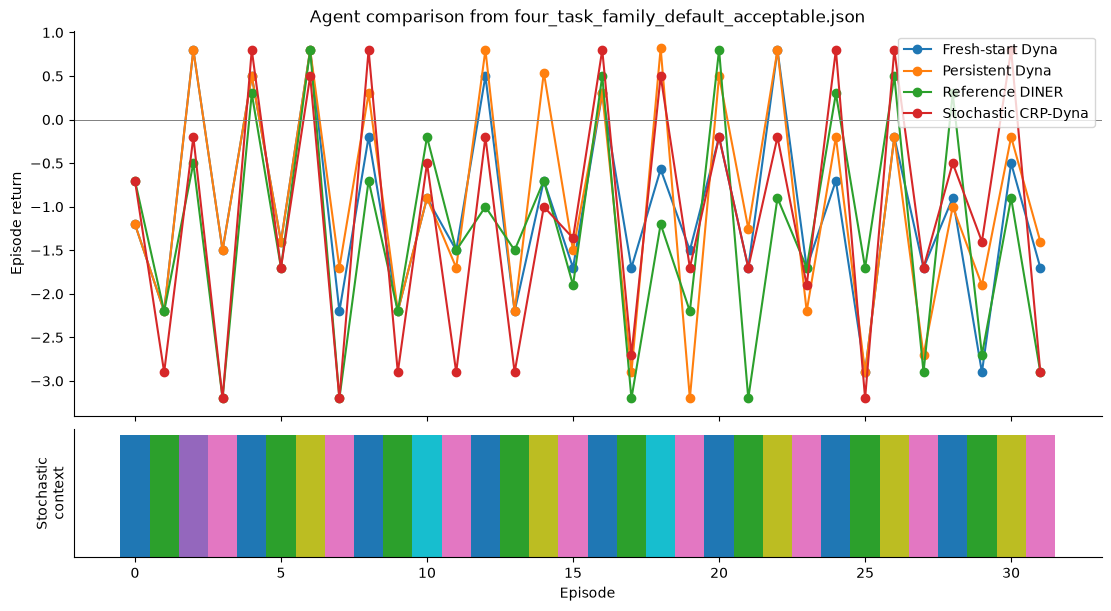

Mean returns:
  fresh-start          -1.033
  persistent           -0.950
  reference DINER      -1.287
  stochastic CRP-Dyna  -1.124


In [36]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]},
                         constrained_layout=True)
axes[0].plot(fresh_returns, marker='o', label='Fresh-start Dyna')
axes[0].plot(persistent_returns, marker='o', label='Persistent Dyna')
axes[0].plot(reference_diner_returns, marker='o', label='Reference DINER')
axes[0].plot(stochastic_result.returns, marker='o', label='Stochastic CRP-Dyna')
axes[0].axhline(0, color='0.5', linewidth=0.7)
axes[0].set_ylabel('Episode return')
axes[0].set_title(f"Agent comparison from {JSON_PATH.name}")
axes[0].legend()

colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(stochastic_agent.contexts))))
for episode, assignment in enumerate(stochastic_result.assignments):
    axes[1].bar(episode, 1, color=colors[assignment], width=1)
axes[1].set(yticks=[], xlabel='Episode', ylabel='Stochastic\ncontext')
plt.show()

print('Mean returns:')
for name, values in {
    'fresh-start': fresh_returns,
    'persistent': persistent_returns,
    'reference DINER': reference_diner_returns,
    'stochastic CRP-Dyna': stochastic_result.returns,
}.items():
    print(f"  {name:20s} {np.mean(values):+.3f}")

## 7. Scaling this smoke test into a planned run

Change only the settings cell, then rerun from the JSON-loading cell:

- increase `EPISODES_PER_TASK` or use `SCHEDULE_MODE="sticky"`;
- increase `PLANNING_STEPS` for stronger Dyna replay;
- increase `STOCHASTIC_PROBE_SAMPLES` for more reliable transition fingerprints;
- use identical schedules and matched seeds across all agents;
- repeat the complete runner across many seeds.

This notebook intentionally does not call `audit_task_family_difficulty`. Run the
separate audit/route cell in the main playground when the design itself needs to be
validated.